# Prototype A4 — 활성집합 제약(box) + adjoint

**A3에서 왜 이 단계가 필요했는가**: $\eta$를 올려 $s$를 정직하게 키우면 순수 Newton이
$C$를 음수로 밀어 발산했다. 이건 버그가 아니라 **강한 비선형에서 제약 없는 Newton이
원래 못 푸는 것**이다. "큰 $s$"와 "강한 비선형"과 "box 제약"은 분리되지 않는다.

**A4가 검증하려는 것**: $C\ge 0$ box 제약이 있는 순전파에서, 그 활성집합을 반영한
**축소 공간 adjoint**가 정확한가.

## 대조군 설계

$\eta$ 4개: $\{0.20,\ 0.35,\ 0.45,\ 0.55\}$

- **$\eta=0.20$ — 대조군.** A3에서 제약 없이도 잘 수렴했던 값(its=4, $|F|$=2.4e-13).
  box를 켜도 활성집합이 비어야 하고, 결과가 A3와 일치해야 한다.
- **$\eta=0.35, 0.45, 0.55$ — 실험군.** 활성집합이 실제로 생겨야 하는 강한 비선형 구간.

| 결과 패턴 | 진단 |
|---|---|
| 대조군 통과 + 실험군 통과 | 전부 정상 |
| **대조군 통과 + 실험군 실패** | **코드는 정상. 활성집합 adjoint나 강한 비선형 자체가 문제** |
| **대조군 실패** | **box 도입 과정에서 배선이 깨짐** — A3까지의 결과와 직접 대조 |

## 축소 공간 adjoint — 오프라인 모의로 검증 완료

$$
K_T^\top\big|_{\mathcal I\mathcal I}\ \psi_{\mathcal I} = \left(\frac{\partial J}{\partial C}\right)_{\mathcal I},
\qquad \psi_{\mathcal A} = 0
$$

$\mathcal I$=비활성(자유) dof, $\mathcal A$=활성($C=0$에 고정) dof. 대조군(활성 0개)과
실험군(활성 2개) 둘 다 유한차분과 기계정밀도로 일치함을 모의로 확인
(대조군 2.3e-10, 실험군 5.4e-9). 부호 규약은 A3와 동일 (`rhs +2r`, VJP `-`).

**전제**: $\theta$를 작게 흔들어도 활성집합이 안 바뀌어야 이 식이 정확하다
(de los Reyes/Meyer의 활성집합 국소 안정성 가정). 노트북은 그래디언트 검증 시
각 $h$에서 활성집합 크기를 함께 출력해 이 전제가 깨지는 지점을 구분한다.

## Cell 1–3 — 환경 (A/A2/A3와 동일, external-operator 불필요)

In [2]:
from google.colab import drive
import os, subprocess
from pathlib import Path

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted')

REPO_URL = 'https://github.com/SeoulTechPSE/fenicsx-colab.git'
REPO_DIR  = Path('/content/fenicsx-colab')
if not REPO_DIR.exists():
    subprocess.run(['git','clone',REPO_URL,str(REPO_DIR)], check=True)
else:
    subprocess.run(['git','-C',str(REPO_DIR),'pull','--quiet'])

N_PROC = 1
with open('/root/hostfile','w') as f:
    f.write(f'localhost slots={N_PROC}\n')
os.environ['OMPI_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'
os.environ['PRTE_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'

%run {REPO_DIR/'setup_fenicsx.py'} --version 0.10

Mounted at /content/drive
🔧 FEniCSx Setup Configuration
DOLFINx version : 0.10
PETSc type      : real
Env name        : fenicsx
Clean install   : False

📦 Google Drive detected — using persistent cache

🔧 Installing FEniCSx environment...

🔍 Verifying installation...
✅ Installed: DOLFINx 0.10.0
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered (env: fenicsx)

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: DOLFINx 0.10 is installed in env 'fenicsx'
   - Real PETSc: recommended for most FEM problems
   - For complex problems, reinstall with --complex


In [3]:
import subprocess
ENV    = 'fenicsx'
PYTHON = f'/content/micromamba/envs/{ENV}/bin/python'

def env_pip(*pkgs, no_deps=False, extra_index=None):
    cmd = [PYTHON, '-m', 'pip', 'install', '--quiet'] + list(pkgs)
    if no_deps:     cmd.append('--no-deps')
    if extra_index: cmd += ['--extra-index-url', extra_index]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0: print('STDERR:', r.stderr[-400:])
    return r.returncode == 0

r = subprocess.run([PYTHON,'-m','pip','--version'], capture_output=True, text=True)
if r.returncode != 0:
    subprocess.run([PYTHON,'-m','ensurepip','--upgrade'], capture_output=True)
    subprocess.run([PYTHON,'-m','pip','install','--upgrade','pip','--quiet'], capture_output=True)

print('Installing PyTorch CPU ...')
ok = env_pip('torch', extra_index='https://download.pytorch.org/whl/cpu')
if not ok: ok = env_pip('torch')
print('OK PyTorch' if ok else 'FAILED PyTorch')

Installing PyTorch CPU ...
OK PyTorch


In [4]:
from pathlib import Path
import os
REPO_DIR = Path('/content/fenicsx-colab')
MAGIC_FILE = REPO_DIR / 'magic' / 'fenicsx_magic.py'
if MAGIC_FILE.exists():
    os.environ['FENICSX_ENV_NAME'] = 'fenicsx'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT'] = '1'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT_CONFIRM'] = '1'
    exec(compile(MAGIC_FILE.read_text(), str(MAGIC_FILE), 'exec'), globals())
    print('%%fenicsx magic registered (env: fenicsx)')
else:
    print('magic file not found - re-run Cell 1')

%%fenicsx magic registered (env: fenicsx)


In [5]:
%%fenicsx
import dolfinx, sys, torch
print(f'DOLFINx : {dolfinx.__version__} | PyTorch : {torch.__version__}')
print('%%fenicsx magic working')

DOLFINx : 0.10.0 | PyTorch : 2.13.0+cpu
%%fenicsx magic working


## Cell 4 — box 처리 방식

PETSc의 `vinewtonrsls`(reduced-space active-set VI solver)를 직접 쓸 수도 있지만,
adjoint 쪽에서 **활성집합을 우리가 직접 알아야** 하므로, A3의 수동 Newton 루프에
**활성집합 트림(trim)**을 얹는 방식을 쓴다 — 모의에서 검증한 것과 동일한 알고리즘이다.

```
① 제약 없는 Newton으로 시험 (A3와 동일)
② C_i < 0 이 된 dof를 활성집합 A로 고정 (C_i = 0)
③ 비활성 dof만의 축소계로 재수렴
④ (반복) ②③이 안정될 때까지 — 활성집합이 안 바뀌면 종료
```

`vinewtonrsls`도 내부적으로 같은 원리(반매끄러운 Newton = 원-쌍대 활성집합 전략,
Hintermüller 2002)로 동작하므로 결과는 동등하다. 수동 구현이 활성집합을
adjoint에 바로 넘기기 더 직접적이라 이 경로를 쓴다.

In [7]:
%%fenicsx
import os, time
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
import ufl, basix
from dolfinx import mesh, fem
from dolfinx.fem import petsc as fem_petsc
from ufl import grad, inner, Measure, derivative
import torch, torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
torch.set_default_dtype(torch.float64)
comm = MPI.COMM_WORLD
OUT = '/content/protoA4_results'; os.makedirs(OUT, exist_ok=True)

# =====================================================================
# 0. PARAMETERS  (identical to A3)
# =====================================================================
R, F_const = 8.314, 96485.0
T_cell = 330.0
K_perm, eps_p = 1.2e-12, 0.30
Lx, w_ch, w_rb = 0.20e-3, 0.8e-3, 1.2e-3
Ly = w_ch + w_rb
y_in_end, y_rib_end = 0.5*w_ch, 0.5*w_ch + w_rb
p_in, p_out = 1.007e5, 1.0e5
mu_g, mu_l = 2.03e-5, 3.15e-4
D_O2_g = 1.775e-5
M_O2, M_N2, M_H2O = 0.032, 0.028, 0.018
rho_l, sigma_st = 1000.0, 0.0625
theta_c = np.deg2rad(91.0)
n_corey = 3.0
X_O2_in = 0.21
I0, alpha_c, C_O2_ref = 100.0, 0.5, 40.0
TAU_TRUE = 1.5

M_mix_in = X_O2_in*M_O2 + (1-X_O2_in)*M_N2
Y_O2_in  = X_O2_in*M_O2/M_mix_in
rho_g    = p_out*M_mix_in/(R*T_cell)
G_REF    = eps_p**TAU_TRUE
DEFF_SCALE = rho_g*D_O2_g

S_MAX, C_HI, C_LO = 0.60, Y_O2_in, 0.02   # s(C) mapping - same as A3, NOT tweaked
nx, ny, qdeg = 12, 30, 2

# =====================================================================
# 1. MESH, TAGS, SPACES  (identical to A3)
# =====================================================================
domain = mesh.create_rectangle(comm, [[0.,0.],[Lx,Ly]], [nx,ny], mesh.CellType.triangle)
V  = fem.functionspace(domain, ('Lagrange', 1))
Qe = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=())
Q  = fem.functionspace(domain, Qe)
Ve = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=(2,))
QV = fem.functionspace(domain, Ve)
dx = Measure('dx', domain=domain, metadata={'quadrature_scheme':'default','quadrature_degree':qdeg})

TAG_MEM, TAG_IN, TAG_RIB, TAG_OUT = 1, 2, 3, 4
def on_mem(x): return np.isclose(x[0], 0.0)
def on_in(x):  return np.isclose(x[0], Lx) & (x[1] <= y_in_end + 1e-12)
def on_rib(x): return np.isclose(x[0], Lx) & (x[1] > y_in_end+1e-12) & (x[1] <= y_rib_end+1e-12)
def on_out(x): return np.isclose(x[0], Lx) & (x[1] > y_rib_end + 1e-12)

fdim = domain.topology.dim - 1
facets, marks = [], []
for tag, fn in [(TAG_MEM,on_mem),(TAG_IN,on_in),(TAG_RIB,on_rib),(TAG_OUT,on_out)]:
    f = mesh.locate_entities_boundary(domain, fdim, fn)
    facets.append(f); marks.append(np.full(len(f), tag, np.int32))
facets = np.hstack(facets); marks = np.hstack(marks); order = np.argsort(facets)
ftags = mesh.meshtags(domain, fdim, facets[order], marks[order])
ds = Measure('ds', domain=domain, subdomain_data=ftags, metadata={'quadrature_degree':qdeg})
nvec = ufl.FacetNormal(domain)

N_dof = V.dofmap.index_map.size_global
print(f'V dof: {N_dof} | Q (quadrature) dof: {Q.dofmap.index_map.size_global}')
_vQ = ufl.TestFunction(Q)
qw = fem_petsc.assemble_vector(fem.form(_vQ*dx)).getArray().copy()

# =====================================================================
# 2. UNKNOWN + s(C)  (identical smoothing to A3 - already validated)
# =====================================================================
C_sol = fem.Function(V)
v_te  = ufl.TestFunction(V)

def s_ufl(C):
    raw = (C_HI - C)/(C_HI - C_LO)
    eps = 0.02
    lo  = 0.5*(raw + ufl.sqrt(raw*raw + eps*eps))
    s01 = 1.0 - 0.5*((1.0-lo) + ufl.sqrt((1.0-lo)**2 + eps*eps))
    return S_MAX*s01

def s_np(C_arr):
    raw = (C_HI - C_arr)/(C_HI - C_LO); eps = 0.02
    lo  = 0.5*(raw + np.sqrt(raw*raw + eps*eps))
    s01 = 1.0 - 0.5*((1.0-lo) + np.sqrt((1.0-lo)**2 + eps*eps))
    return S_MAX*s01

s_expr = s_ufl(C_sol)

def make_closures(s):
    krl, krg = s**n_corey, (1.0-s)**n_corey
    lam_l = (krl/mu_l)/(krl/mu_l + krg/mu_g + 1e-30)
    lam_g = 1.0 - lam_l
    nu_mix = 1.0/(krg/(mu_g/rho_g) + krl/(mu_l/rho_l) + 1e-30)
    rho_mix = rho_g*(1.0-s) + rho_l*s
    kappa  = rho_mix*K_perm/(nu_mix*rho_mix + 1e-30)
    dJds   = 1.417 - 4.240*s + 3.789*s**2
    Dc = (lam_l*lam_g*K_perm/(nu_mix+1e-30))*sigma_st*np.cos(theta_c)*(eps_p/K_perm)**0.5*dJds
    return rho_mix, kappa, lam_g, Dc

rho_mix, kappa, lam_g, Dc = make_closures(s_expr)

# =====================================================================
# 3. Deff via manual quadrature Functions  (A3's final working scheme -
#    external-operator was tried and abandoned: FormSum bug in the
#    self-referential case; see conversation history)
# =====================================================================
Deff_fn  = fem.Function(Q)
dDeff_fn = fem.Function(Q)

model = None   # DeffNet, set below

def update_Deff():
    """Re-evaluate the network at the CURRENT C_sol. Called every Newton
    iteration -> equation never shifts (this is what fixed A3's v1 bug)."""
    Cq = fem.Function(Q); Cq.interpolate(fem.Expression(C_sol, Q.element.interpolation_points))
    s_q = s_np(Cq.x.array)
    s_t = torch.tensor(s_q, requires_grad=True)
    G = model(s_t)
    dG, = torch.autograd.grad(G.sum(), s_t)
    Deff_fn.x.array[:]  = DEFF_SCALE*G.detach().numpy()
    dDeff_fn.x.array[:] = DEFF_SCALE*dG.detach().numpy()
    return s_q

C_tr = ufl.TrialFunction(V)
ds_dC_dir = derivative(s_ufl(C_sol), C_sol, C_tr)   # UFL differentiates s(C) analytically

# =====================================================================
# 4. RESIDUAL, TANGENT (K_std + K_corr, explicit UFL derivative), Robin
# =====================================================================
p_sol = fem.Function(V)
u_darcy = -(kappa/rho_mix)*grad(p_sol)
W_O2 = rho_mix*lam_g*u_darcy
Jl_vec = Dc*grad(s_expr)

def smooth_out(x, e=1e-5): return 0.5*(x + ufl.sqrt(x*x + e*e))

ETA_c = fem.Constant(domain, PETSc.ScalarType(0.0))
tafel_expr = (1.0 - s_expr)*I0*rho_g/(4.0*F_const*C_O2_ref)*ufl.exp(alpha_c*F_const*ETA_c/(R*T_cell))

F_res = ( Deff_fn*inner(grad(C_sol), grad(v_te))*dx
        - C_sol*inner(W_O2, grad(v_te))*dx
        + C_sol*inner(Jl_vec, grad(v_te))*dx
        + C_sol*smooth_out(inner(W_O2, nvec))*v_te*ds(TAG_OUT)
        + tafel_expr*C_sol*v_te*ds(TAG_MEM) )

J_std = derivative(F_res, C_sol, C_tr)                                   # Deff_fn held fixed
J_corr = dDeff_fn*ds_dC_dir*inner(grad(C_sol), grad(v_te))*dx            # K_corr, explicit
J_tan  = J_std + J_corr

F_form, J_form = fem.form(F_res), fem.form(J_tan)

dofs_C_in = fem.locate_dofs_geometrical(V, on_in)
bc_C = fem.dirichletbc(PETSc.ScalarType(Y_O2_in), dofs_C_in, V)
bc_rows = set(bc_C.dof_indices()[0].tolist())

# --- pressure (frozen at cold start, independent of theta) ---
p_tr, p_teF = ufl.TrialFunction(V), ufl.TestFunction(V)
kap_p = fem.Function(V)
a_p = fem.form(kap_p*inner(grad(p_tr), grad(p_teF))*dx)
L_p = fem.form(fem.Constant(domain, PETSc.ScalarType(0.0))*p_teF*dx)
dofs_p_in, dofs_p_out = fem.locate_dofs_geometrical(V, on_in), fem.locate_dofs_geometrical(V, on_out)
bcs_p = [fem.dirichletbc(PETSc.ScalarType(p_in-p_out), dofs_p_in, V),
         fem.dirichletbc(PETSc.ScalarType(0.0), dofs_p_out, V)]
kap_expr_V = fem.Expression(kappa, V.element.interpolation_points)

def solve_pressure():
    kap_p.interpolate(kap_expr_V)
    A = fem_petsc.assemble_matrix(a_p, bcs=bcs_p); A.assemble()
    b = fem_petsc.assemble_vector(L_p)
    fem_petsc.apply_lifting(b,[a_p],[bcs_p]); b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(b, bcs_p)
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')
    ksp.solve(b, p_sol.x.petsc_vec); p_sol.x.scatter_forward(); ksp.destroy(); A.destroy(); b.destroy()

# =====================================================================
# 5. NETWORK
# =====================================================================
class DeffNet(nn.Module):
    def __init__(self, hidden=30):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,hidden), nn.Tanh(),
                                 nn.Linear(hidden,hidden), nn.Tanh(),
                                 nn.Linear(hidden,1), nn.Softplus())
        with torch.no_grad(): self.net[-2].bias.fill_(0.5413)
    def forward(self, s): return (self.net(s.reshape(-1,1))*G_REF).reshape(s.shape)

model = DeffNet()
print(f'DeffNet: {sum(p.numel() for p in model.parameters())} params | G_REF={G_REF:.4f}')

# =====================================================================
# 6. BOX-CONSTRAINED (C>=0) NEWTON  --  the new element in A4
#    Step 1: unconstrained trial (A3-style)
#    Step 2: dofs that went negative -> fixed at 0 (active set)
#    Step 3: resolve on the reduced (inactive) system
#    Step 4: repeat 2-3 until the active set stabilises
#    (equivalent to primal-dual active-set / vinewtonrsls; validated offline)
# =====================================================================
def assemble_FA(dof_rows_zero):
    """Assemble F, zeroing residual rows in dof_rows_zero (BC- or active-set-like)."""
    update_Deff()
    b = fem_petsc.assemble_vector(F_form)
    arr = b.getArray()
    for i in dof_rows_zero: arr[i] = 0.0
    b.setArray(arr)
    return b

def assemble_JA(fixed_rows):
    """Assemble J with fixed_rows treated as Dirichlet-like (identity rows)."""
    bc_fixed = [fem.dirichletbc(PETSc.ScalarType(0.0),
                    np.array(sorted(fixed_rows), dtype=np.int32), V)] if fixed_rows else []
    all_bcs = [bc_C] + bc_fixed
    A = fem_petsc.assemble_matrix(J_form, bcs=all_bcs); A.assemble()
    return A, all_bcs

def newton_on_active_set(active, tol=1e-11, max_it=30):
    """Inner Newton with `active` dofs pinned at their current (=0) value."""
    fixed = bc_rows | active
    it, nF = 0, 1.0
    for it in range(max_it):
        b = assemble_FA(fixed); nF = b.norm()
        if nF < tol: b.destroy(); break
        A, all_bcs = assemble_JA(active)
        dC = A.createVecRight()
        ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')
        ksp.solve(b, dC)
        C_sol.x.array[:] -= dC.array[:]; C_sol.x.scatter_forward()
        ksp.destroy(); A.destroy(); b.destroy(); dC.destroy()
    return it, nF

def box_newton_solve(eta, max_outer=6, verbose=False):
    ETA_c.value = eta
    C_sol.x.array[:] = Y_O2_in; C_sol.x.array[list(bc_rows)] = Y_O2_in
    solve_pressure()
    active = set()
    for outer in range(max_outer):
        it, nF = newton_on_active_set(active)
        neg = set(np.where(C_sol.x.array < -1e-10)[0].tolist()) - bc_rows
        if verbose:
            print(f'  outer{outer}: inner its={it:2d} |F|={nF:.2e} '
                  f'active={len(active):2d} newly-negative={len(neg):2d}')
        if not neg:
            return outer, it, nF, active
        C_sol.x.array[list(neg)] = 0.0; C_sol.x.scatter_forward()
        active |= neg
    return max_outer, it, nF, active

# =====================================================================
# 7. SYNTHETIC OBSERVATIONS  -- eta = {0.20 CONTROL, 0.35, 0.45, 0.55}
# =====================================================================
class TrueGModel:
    def __call__(self, s_t):
        s_c = torch.clamp(s_t, 0.0, 0.99)
        return (eps_p*(1.0-s_c))**TAU_TRUE
_true_model = TrueGModel()

def box_newton_solve_true(eta, **kw):
    global model
    old = model; model = _true_model
    try:
        return box_newton_solve(eta, **kw)
    finally:
        model = old

def G_true_np(s): return (eps_p*(1.0-np.clip(s,0,0.99)))**TAU_TRUE

ETAS, NOISE = [0.20, 0.35, 0.45, 0.55], 0.02
samples = []
print('\\nGenerating ground-truth data (true tau=1.5):')
for eta in ETAS:
    outer, it, nF, active = box_newton_solve_true(eta)
    C_clean = C_sol.x.array.copy()
    ok = np.all(np.isfinite(C_clean)) and nF < 1e-8
    tag = 'CONTROL' if eta == 0.20 else 'exp'
    print(f'  eta={eta} [{tag}]: outer={outer}, inner its={it}, |F|={nF:.2e}, '
          f'active dofs={len(active)}, s reached [{s_np(C_clean).min():.3f}, {s_np(C_clean).max():.3f}]'
          + ('' if ok else '  <-- NOT CONVERGED, skipping'))
    if not ok: continue
    obs = C_clean + NOISE*np.std(C_clean)*np.random.randn(N_dof)
    samples.append(dict(eta=eta, obs=obs, active_gt=active))

assert len(samples) >= 3, 'not enough converged GT samples'
control_sample = [s for s in samples if s['eta']==0.20]
exp_samples     = [s for s in samples if s['eta']!=0.20]
train = control_sample + exp_samples[:2]
test  = exp_samples[2:]
print(f'train: {len(train)}  test: {len(test)}')

# =====================================================================
# 8. FORWARD + REDUCED-SPACE ADJOINT + VJP  (A3 nonlinear sign: rhs +2r, VJP -)
# =====================================================================
gradC_q, gradP_q = fem.Function(QV), fem.Function(QV)
psi_fn = fem.Function(V)
ip = QV.element.interpolation_points

def loss_and_vjp(sample, want_grad=True):
    obs = sample['obs']
    outer, it, nF, active = box_newton_solve(sample['eta'])
    C_np = C_sol.x.array.copy()
    if not np.all(np.isfinite(C_np)):
        raise FloatingPointError('non-finite solution')
    denom = max(float(np.dot(obs,obs)), 1e-30)
    r = C_np - obs
    Jv = float(np.dot(r,r))/denom
    if not want_grad:
        return Jv, None, active

    fixed = bc_rows | active                        # reduced space: fix BC + active dofs
    A, all_bcs = assemble_JA(active)                 # converged tangent, box rows treated as identity
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')

    rhs = A.createVecLeft(); rr = 2.0*r/denom
    for i in fixed: rr[i] = 0.0                      # psi_A = 0 (and psi on Dirichlet rows = 0)
    rhs.setArray(rr)
    psi_v = A.createVecRight()
    ksp.solveTranspose(rhs, psi_v)
    psi_fn.x.array[:] = psi_v.array[:]; psi_fn.x.scatter_forward()

    exprC = fem.Expression(grad(C_sol), ip); exprP = fem.Expression(grad(psi_fn), ip)
    gradC_q.interpolate(exprC); gradP_q.interpolate(exprP)
    gC = gradC_q.x.array.reshape(-1,2); gP = gradP_q.x.array.reshape(-1,2)
    dJdDeff = -qw*(gC*gP).sum(axis=1)
    rhs.destroy(); psi_v.destroy(); ksp.destroy(); A.destroy()
    return Jv, dJdDeff, active

def get_s_qp():
    Cq = fem.Function(Q); Cq.interpolate(fem.Expression(C_sol, Q.element.interpolation_points))
    return s_np(Cq.x.array)

def epoch_grad(dataset):
    model.zero_grad(); tot = 0.0
    for sm in dataset:
        Jv, dJdDeff, active = loss_and_vjp(sm); tot += Jv
        s_qp = get_s_qp()
        G_t = model(torch.tensor(s_qp))
        dJdG = dJdDeff*DEFF_SCALE
        G_t.backward(torch.tensor(dJdG)/len(dataset))
    return tot/len(dataset)

def dataset_loss(dataset):
    return float(np.mean([loss_and_vjp(sm, want_grad=False)[0] for sm in dataset]))

# =====================================================================
# 9. GRADIENT VERIFICATION  --  per-eta, with active-set size tracked per h
# =====================================================================
from torch.nn.utils import parameters_to_vector, vector_to_parameters

def grad_check_one(sample, label):
    print(f'\\n--- {label} (eta={sample["eta"]}) ---')
    model.zero_grad()
    J0, dJdDeff, active0 = loss_and_vjp(sample)
    s_qp = get_s_qp(); G_t = model(torch.tensor(s_qp))
    dJdG = dJdDeff*DEFF_SCALE
    G_t.backward(torch.tensor(dJdG))
    g0 = parameters_to_vector([p.grad for p in model.parameters()]).detach().clone()
    th0 = parameters_to_vector(model.parameters()).detach().clone()
    d = torch.randn_like(th0); d /= d.norm(); slope = float(torch.dot(g0,d))
    print(f'  J0={J0:.6e}  active(converged)={len(active0)}')
    print('      h            ratio        |ratio-1|   active(h)')
    best = 1e9
    for h in [1e-2,1e-3,1e-4,1e-5,1e-6,1e-7]:
        vector_to_parameters(th0 + h*d, model.parameters())
        Jh, _, active_h = loss_and_vjp(sample, want_grad=False)
        ratio = (Jh-J0)/(h*slope); best = min(best, abs(ratio-1.0))
        flag = '' if len(active_h)==len(active0) else '  <-- ACTIVE SET CHANGED'
        print(f'    {h:.0e}     {ratio:12.8f}   {abs(ratio-1.0):.3e}   {len(active_h):3d}{flag}')
    vector_to_parameters(th0, model.parameters())
    print(f'  best |ratio-1| = {best:.2e}  {"PASS" if best<1e-3 else "FAIL"}')
    return best, len(active0)

print('='*70); print('GRADIENT VERIFICATION (per eta - control isolates code bugs'); print('='*70)
results = {}
for sm in train:
    label = 'CONTROL' if sm['eta']==0.20 else 'experiment'
    best, nact = grad_check_one(sm, label)
    results[sm['eta']] = (best, nact)
print('\\n' + '='*70)
print('SUMMARY')
for eta,(best,nact) in results.items():
    tag = 'CONTROL' if eta==0.20 else 'exp'
    print(f'  eta={eta} [{tag}]: active={nact}  best|ratio-1|={best:.2e}  '
          f'{"PASS" if best<1e-3 else "FAIL"}')
ctrl_ok = results.get(0.20, (1e9,0))[0] < 1e-3
exp_ok  = all(v[0]<1e-3 for k,v in results.items() if k!=0.20)
print(f'\\nControl {"PASS" if ctrl_ok else "FAIL"} / Experiment {"PASS" if exp_ok else "FAIL"}')
if ctrl_ok and not exp_ok:
    print('-> code is correct; failure is specific to the active-set case')
elif not ctrl_ok:
    print('-> control itself fails: something broke UPSTREAM of the box logic')
print('='*70 + '\\n')

# =====================================================================
# 10. TRAINING
# =====================================================================
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=600, eta_min=1e-5)
n_ep, patience = 600, 120
best_test, no_imp, best_state, best_ep = 1e30, 0, None, -1
hist = {'train':[], 'test':[]}; t0 = time.time()
print(' Epoch |       Train |        Test |   Time'); print('-'*50)
for ep in range(n_ep):
    tl = epoch_grad(train)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
    vl = dataset_loss(test); hist['train'].append(tl); hist['test'].append(vl)
    if vl < best_test:
        best_test, no_imp, best_ep = vl, 0, ep
        best_state = {k:v.clone() for k,v in model.state_dict().items()}
    else:
        no_imp += 1
        if no_imp >= patience: print(f'Early stop @ ep {ep}'); break
    if ep % 20 == 0: print(f'{ep:6d} | {tl:11.4e} | {vl:11.4e} | {time.time()-t0:6.1f}s')
if best_state: model.load_state_dict(best_state)
print(f'\\nTime: {time.time()-t0:.1f}s | Best epoch: {best_ep}')

# =====================================================================
# 11. EVALUATE
# =====================================================================
s_plot = np.linspace(0.0, 0.85, 200)
with torch.no_grad(): G_ml = model(torch.tensor(s_plot)).numpy()
G_gt = G_true_np(s_plot)
S_LO, S_HI = 0.0, S_MAX
inside = (s_plot>=S_LO)&(s_plot<=S_HI)
err_in = np.mean(np.abs(G_ml[inside]-G_gt[inside])/G_gt[inside])*100
print(f'\\nG(s) mean rel. error INSIDE [{S_LO:.2f},{S_HI:.2f}] : {err_in:.1f}%')
print('band-wise:')
for a,b in [(0,0.2),(0.2,0.4),(0.4,0.6)]:
    m=(s_plot>=a)&(s_plot<b); rel=np.abs(G_ml[m]-G_gt[m])/G_gt[m]*100
    print(f'  s in [{a},{b}): mean {rel.mean():5.1f}%  (n={m.sum()})')
np.savez(os.path.join(OUT,'protoA4.npz'), s_plot=s_plot, G_ml=G_ml, G_gt=G_gt,
         train=np.array(hist['train']), test=np.array(hist['test']),
         S_LO=S_LO, S_HI=S_HI, err_in=err_in,
         grad_check_control=results.get(0.20,(np.nan,0))[0],
         grad_check_exp_worst=max(v[0] for k,v in results.items() if k!=0.20))
print(f'saved -> {OUT}/protoA4.npz')


V dof: 403 | Q (quadrature) dof: 2160
DeffNet: 1021 params | G_REF=0.1643
\nGenerating ground-truth data (true tau=1.5):
  eta=0.2 [CONTROL]: outer=0, inner its=4, |F|=2.39e-13, active dofs=0, s reached [0.000, 0.057]
  eta=0.35 [exp]: outer=1, inner its=5, |F|=2.69e-14, active dofs=3, s reached [0.006, 0.599]
  eta=0.45 [exp]: outer=3, inner its=0, |F|=1.70e-14, active dofs=115, s reached [0.006, 0.599]
  eta=0.55 [exp]: outer=2, inner its=1, |F|=2.76e-15, active dofs=72, s reached [0.006, 0.599]
train: 3  test: 1
GRADIENT VERIFICATION (per eta - control isolates code bugs
\n--- CONTROL (eta=0.2) ---
  J0=1.246054e-06  active(converged)=0
      h            ratio        |ratio-1|   active(h)
    1e-02       0.98953940   1.046e-02     0
    1e-03       0.99895423   1.046e-03     0
    1e-04       0.99989526   1.047e-04     0
    1e-05       0.99998936   1.064e-05     0
    1e-06       0.99999881   1.193e-06     0
    1e-07       0.99999996   3.832e-08     0
  best |ratio-1| = 3.83e-08 

## Cell 6 — 결과 플롯

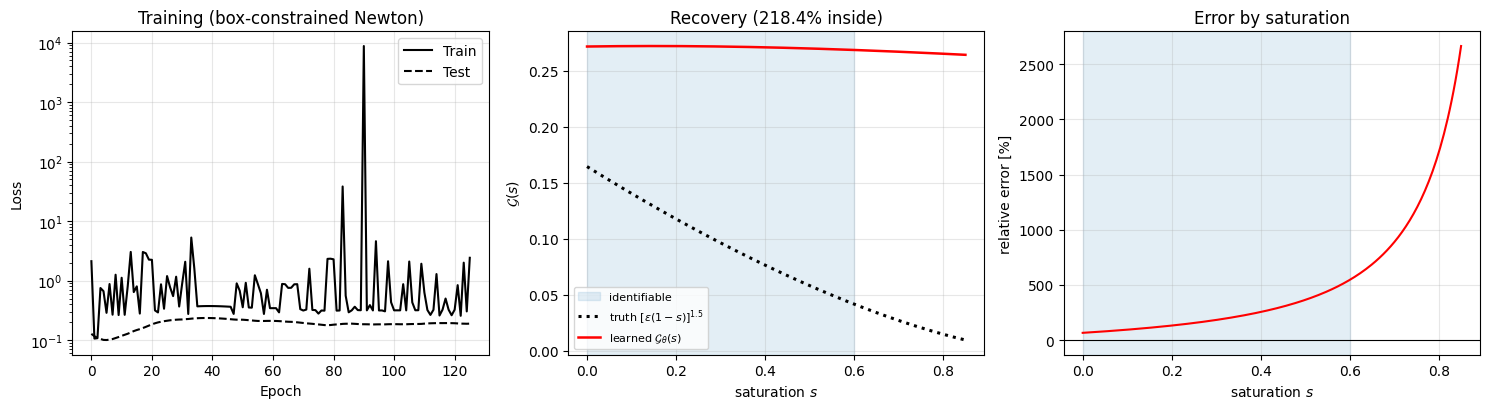

control  best |ratio-1| : 3.83e-08
exp worst best |ratio-1| : 3.69e+04


In [8]:
import numpy as np, matplotlib.pyplot as plt
d = np.load('/content/protoA4_results/protoA4.npz')
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].semilogy(d['train'],'k-',label='Train'); ax[0].semilogy(d['test'],'k--',label='Test')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
ax[0].set_title('Training (box-constrained Newton)'); ax[0].grid(alpha=.3)
s,gm,gg=d['s_plot'],d['G_ml'],d['G_gt']; lo,hi=float(d['S_LO']),float(d['S_HI'])
ax[1].axvspan(lo,hi,color='tab:blue',alpha=.12,label='identifiable')
ax[1].plot(s,gg,'k:',lw=2.2,label=r'truth $[\varepsilon(1-s)]^{1.5}$')
ax[1].plot(s,gm,'r-',lw=1.8,label=r'learned $\mathcal{G}_\theta(s)$')
ax[1].set_xlabel('saturation $s$'); ax[1].set_ylabel(r'$\mathcal{G}(s)$')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); ax[1].set_title(f"Recovery ({float(d['err_in']):.1f}% inside)")
rel=(gm-gg)/gg*100
ax[2].axvspan(lo,hi,color='tab:blue',alpha=.12); ax[2].axhline(0,color='k',lw=.8); ax[2].plot(s,rel,'r-')
ax[2].set_xlabel('saturation $s$'); ax[2].set_ylabel('relative error [%]'); ax[2].set_title('Error by saturation'); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"control  best |ratio-1| : {float(d['grad_check_control']):.2e}")
print(f"exp worst best |ratio-1| : {float(d['grad_check_exp_worst']):.2e}")


## 판정 기준

| 항목 | 통과 |
|---|---|
| **§7 활성집합 개수** | $\eta=0.20$은 0, 나머지는 >0 (전제조건 — 0이면 실험 자체가 무의미) |
| **§9 대조군** | `\|ratio-1\|` < 1e-3, A3의 3.75e-6과 유사한 수준이어야 함 |
| **§9 실험군** | `\|ratio-1\|` < 1e-3, 각 $\eta$별 개별 확인 |
| §9 "ACTIVE SET CHANGED" 플래그 | 뜨는 $h$ 근처 결과는 판정에서 제외 (그 지점은 원래 비미분점) |

**대조군이 실패하면** box 도입 과정에서 상위 배선(BC 처리, 잔차 조립)이 깨진 것 —
A3 결과와 직접 비교해 어디서 달라졌는지 확인.

**대조군은 통과, 실험군만 실패하면** 활성집합 adjoint 로직 자체(축소 공간 구성,
`fixed`/`active` 인덱싱)를 의심.

## 다음 단계

A4까지 통과하면 **단일 필드에서 마주칠 수 있는 모든 난점이 검증 완료**된다:
선형 배선(A) → 경계항(A2) → 자기참조 비선형(A3) → box 제약(A4).
남은 축은 B의 **mixed space**뿐이다.